In [4]:
import pandas as pd
import numpy as np

def remove_outliers_iqr(df, metrics=['imse', 'imae', 'maxerr']):
    """
    Удаляет выбросы по методу 1.5 IQR для указанных метрик.
    """
    if len(df) < 4:
        return df.copy(), 0
    
    df_clean = df.copy()
    n_removed_total = 0
    
    # Создаём единую маску для всех метрик
    global_mask = np.ones(len(df_clean), dtype=bool)
    
    for metric in metrics:
        if metric not in df_clean.columns:
            continue
        
        # Работаем с копией данных для расчёта квантилей (исключаем NaN)
        valid_data = df_clean[metric].dropna()
        
        if len(valid_data) < 4:
            continue
        
        q1 = valid_data.quantile(0.25)
        q3 = valid_data.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Создаём маску для текущей метрики
        metric_mask = (df_clean[metric] >= lower_bound) & (df_clean[metric] <= upper_bound)
        metric_mask = metric_mask.fillna(False)  # NaN считаем выбросами (удаляем)
        
        # Объединяем с общей маской (логическое И)
        global_mask = global_mask & metric_mask.values
    
    # Применяем маску один раз в конце
    n_removed_total = len(df_clean) - np.sum(global_mask)
    df_clean = df_clean[global_mask].reset_index(drop=True)
    
    return df_clean, n_removed_total


def aggregate_metrics(df, group_cols=['generation_type']):
    """
    Агрегирует метрики по указанным группам.
    """
    agg_dict = {
        'imse': ['mean', 'sem'],
        'imae': ['mean', 'sem'],
        'maxerr': ['mean', 'sem']
    }
    
    agg_df = df.groupby(group_cols).agg(agg_dict).reset_index()
    
    # Переименовываем колонки (убираем многоуровневые названия)
    agg_df.columns = ['generation_type', 
                      'imse_mean', 'imse_sem',
                      'imae_mean', 'imae_sem', 
                      'maxerr_mean', 'maxerr_sem']
    
    # Добавляем количество записей
    counts = df.groupby(group_cols).size().reset_index(name='n_valid')
    agg_df = agg_df.merge(counts, on='generation_type')
    
    return agg_df


def run_entropy_aggregation(input_file='mixture_results_all.csv'):
    """
    Запускает агрегацию метрик для энтропийного метода двумя способами.
    """
    # Загрузка данных
    print("Загрузка данных...")
    df = pd.read_csv(input_file)
    print(f"Загружено {len(df)} записей")
    print(f"Колонки: {df.columns.tolist()}")
    
    # ========================================================================
    # 1) Агрегация БЕЗ удаления выбросов
    # ========================================================================
    print("\n" + "="*80)
    print("1) Агрегация БЕЗ удаления выбросов")
    print("="*80)
    
    agg_before = aggregate_metrics(df.copy(), group_cols=['generation_type'])
    agg_before['method'] = 'entropy'
    agg_before['n_total'] = len(df)
    agg_before['n_outliers_removed'] = 0
    
    # Переупорядочиваем колонки как в kernel_regression файлах
    agg_before = agg_before[['generation_type', 'method', 'n_total', 'n_valid', 
                              'n_outliers_removed', 'imse_mean', 'imse_sem',
                              'imae_mean', 'imae_sem', 'maxerr_mean', 'maxerr_sem']]
    
    print("\nРезультаты до удаления выбросов:")
    print(agg_before.to_string(index=False))
    
    # ========================================================================
    # 2) Удаление выбросов по 1.5 IQR и агрегация
    # ========================================================================
    print("\n" + "="*80)
    print("2) Удаление выбросов по методу 1.5 IQR и агрегация")
    print("="*80)
    
    df_clean, n_removed = remove_outliers_iqr(df.copy(), metrics=['imse', 'imae', 'maxerr'])
    print(f"Удалено выбросов: {n_removed} ({n_removed/len(df)*100:.2f}%)")
    print(f"Осталось записей: {len(df_clean)}")
    
    agg_after = aggregate_metrics(df_clean, group_cols=['generation_type'])
    agg_after['method'] = 'entropy'
    agg_after['n_total'] = len(df)
    agg_after['n_outliers_removed'] = 300 - agg_after['n_valid']
    
    # Переупорядочиваем колонки
    agg_after = agg_after[['generation_type', 'method', 'n_total', 'n_valid', 
                            'n_outliers_removed', 'imse_mean', 'imse_sem',
                            'imae_mean', 'imae_sem', 'maxerr_mean', 'maxerr_sem']]
    
    print("\nРезультаты после удаления выбросов:")
    print(agg_after.to_string(index=False))
    
    # ========================================================================
    # Сохранение результатов
    # ========================================================================
    print("\n" + "="*80)
    print("Сохранение результатов")
    print("="*80)
    
    # Сохраняем файлы
    agg_before.to_csv('entropy_mixture_results_before_iqr.csv', index=False)
    agg_after.to_csv('entropy_mixture_results_after_iqr.csv', index=False)
    
    print(f"\n✅ Сохранено:")
    print(f"   - entropy_mixture_results_before_iqr.csv ({len(agg_before)} строк)")
    print(f"   - entropy_mixture_results_after_iqr.csv ({len(agg_after)} строк)")
    

    
    return agg_before, agg_after


# Запуск
if __name__ == "__main__":
    agg_before, agg_after = run_entropy_aggregation('mixture_results_all.csv')

Загрузка данных...
Загружено 600 записей
Колонки: ['dataset_id', 'generation_type', 'seed', 'imse', 'imae', 'maxerr', 'n_samples']

1) Агрегация БЕЗ удаления выбросов

Результаты до удаления выбросов:
generation_type  method  n_total  n_valid  n_outliers_removed  imse_mean  imse_sem  imae_mean  imae_sem  maxerr_mean  maxerr_sem
  deterministic entropy      600      300                   0   0.790338  0.202259   0.247701  0.018200     1.329225    0.192199
     stochastic entropy      600      300                   0   1.124104  0.251977   0.275951  0.021856     1.603474    0.231542

2) Удаление выбросов по методу 1.5 IQR и агрегация
Удалено выбросов: 104 (17.33%)
Осталось записей: 496

Результаты после удаления выбросов:
generation_type  method  n_total  n_valid  n_outliers_removed  imse_mean  imse_sem  imae_mean  imae_sem  maxerr_mean  maxerr_sem
  deterministic entropy      600      252                  48   0.055350  0.001993   0.155598   0.00332     0.410550    0.013743
     stochas

ОБЩАЯ СТАТИСТИКА ПО ПАРАМЕТРАМ

Всего записей: 600

Распределение по типу генерации:
generation_type
deterministic    300
stochastic       300
Name: count, dtype: int64

Статистики по степени полинома (selected_degree):
                 count      mean       std  min  25%  50%  75%  max
generation_type                                                    
deterministic    300.0  2.063333  1.109094  1.0  1.0  2.0  2.0  6.0
stochastic       300.0  2.186667  1.261133  1.0  1.0  2.0  2.0  6.0

Статистики по доле c1:
                 count      mean       std  min  25%       50%       75%  max
generation_type                                                              
deterministic    300.0  0.383175  0.330473  0.0  0.0  0.333333  0.666667  1.0
stochastic       300.0  0.379746  0.349775  0.0  0.0  0.380952  0.666667  1.0

Статистики по доле c2:
                 count      mean       std  min       25%       50%  75%  max
generation_type                                                       

C:\Users\M A C H R E A T O R\AppData\Local\Temp\ipykernel_4696\440013250.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='generation_type', y='c1', ax=axes[0], palette=['steelblue', 'coral'])


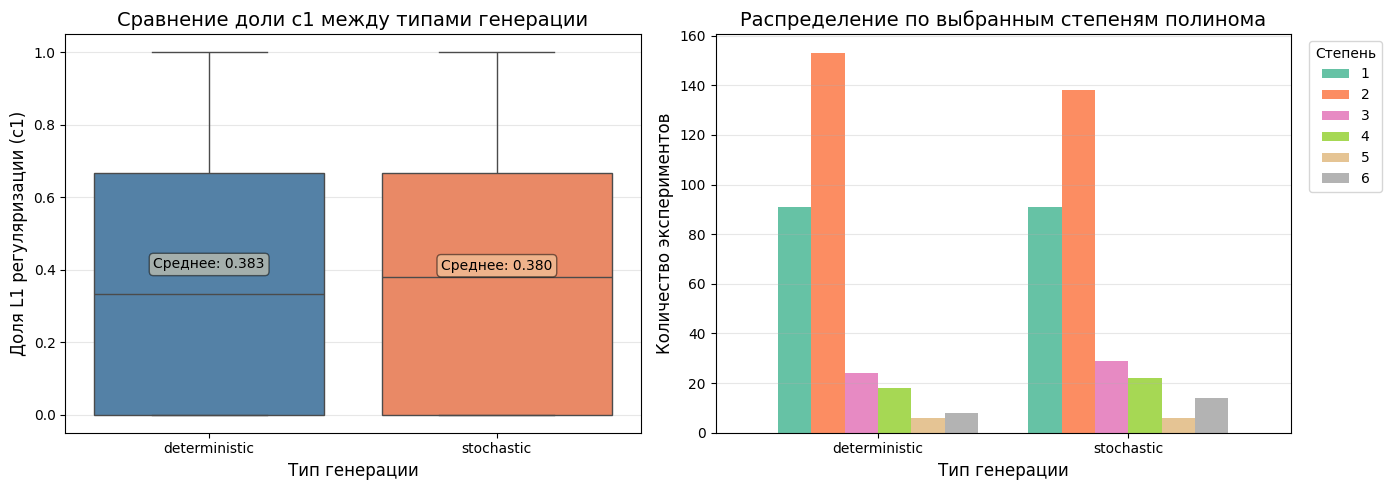


РАСПРЕДЕЛЕНИЕ ПО СТЕПЕНЯМ ПОЛИНОМА

Детальный подсчёт по степеням и типам генерации:
selected_degree    1    2   3   4   5   6  All
generation_type                               
deterministic     91  153  24  18   6   8  300
stochastic        91  138  29  22   6  14  300
All              182  291  53  40  12  22  600

СТАТИСТИКА ПО КОЛИЧЕСТВУ КОЭФФИЦИЕНТОВ
                 count      mean       std  min  25%  50%  75%  max
generation_type                                                    
deterministic    300.0  3.063333  1.109094  2.0  2.0  3.0  3.0  7.0
stochastic       300.0  3.186667  1.261133  2.0  2.0  3.0  3.0  7.0


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# Загрузка данных
df = pd.read_csv('mixture_params_all.csv')

# Парсинг коэффициентов (список в строке)
df['coefficients'] = df['coefficients'].apply(lambda x: json.loads(x))
df['n_coefficients'] = df['coefficients'].apply(len)

# Статистики по параметрам
print("=" * 60)
print("ОБЩАЯ СТАТИСТИКА ПО ПАРАМЕТРАМ")
print("=" * 60)
print(f"\nВсего записей: {len(df)}")
print(f"\nРаспределение по типу генерации:")
print(df['generation_type'].value_counts())
print(f"\nСтатистики по степени полинома (selected_degree):")
print(df.groupby('generation_type')['selected_degree'].describe())
print(f"\nСтатистики по доле c1:")
print(df.groupby('generation_type')['c1'].describe())
print(f"\nСтатистики по доле c2:")
print(df.groupby('generation_type')['c2'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Boxplot сравнения доли c1 между генерациями
sns.boxplot(data=df, x='generation_type', y='c1', ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_xlabel('Тип генерации', fontsize=12)
axes[0].set_ylabel('Доля L1 регуляризации (c1)', fontsize=12)
axes[0].set_title('Сравнение доли c1 между типами генерации', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения средних
means = df.groupby('generation_type')['c1'].mean()
for i, gen_type in enumerate(df['generation_type'].unique()):
    axes[0].text(i, means[gen_type] + 0.02, f'Среднее: {means[gen_type]:.3f}', 
                 ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# График 2: Распределение по степеням полинома
degree_counts = df.groupby(['generation_type', 'selected_degree']).size().unstack(fill_value=0)
degree_counts.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.8)
axes[1].set_xlabel('Тип генерации', fontsize=12)
axes[1].set_ylabel('Количество экспериментов', fontsize=12)
axes[1].set_title('Распределение по выбранным степеням полинома', fontsize=14)
axes[1].legend(title='Степень', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mixture_params_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Дополнительная статистика по степеням
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ПО СТЕПЕНЯМ ПОЛИНОМА")
print("=" * 60)
print("\nДетальный подсчёт по степеням и типам генерации:")
print(pd.crosstab(df['generation_type'], df['selected_degree'], margins=True))

# Статистика по количеству коэффициентов
print("\n" + "=" * 60)
print("СТАТИСТИКА ПО КОЛИЧЕСТВУ КОЭФФИЦИЕНТОВ")
print("=" * 60)
print(df.groupby('generation_type')['n_coefficients'].describe())

АНАЛИЗ ВЛИЯНИЯ УДАЛЕНИЯ ВЫБРОСОВ (IQR)

Сводная таблица:
generation_type  n_total  n_valid_before  imse_mean_before  n_valid_after  n_outliers_removed  imse_mean_after  removal_rate  imse_reduction
  deterministic      600             300          0.790338            252                  48         0.055350     16.000000       92.996618
     stochastic      600             300          1.124104            244                  56         0.056509     18.666667       94.972940

КЛЮЧЕВЫЕ МЕТРИКИ

DETERMINISTIC:
  • Доля удалённых выбросов: 16.0%
  • Уменьшение IMSE: 93.0%

STOCHASTIC:
  • Доля удалённых выбросов: 18.7%
  • Уменьшение IMSE: 95.0%


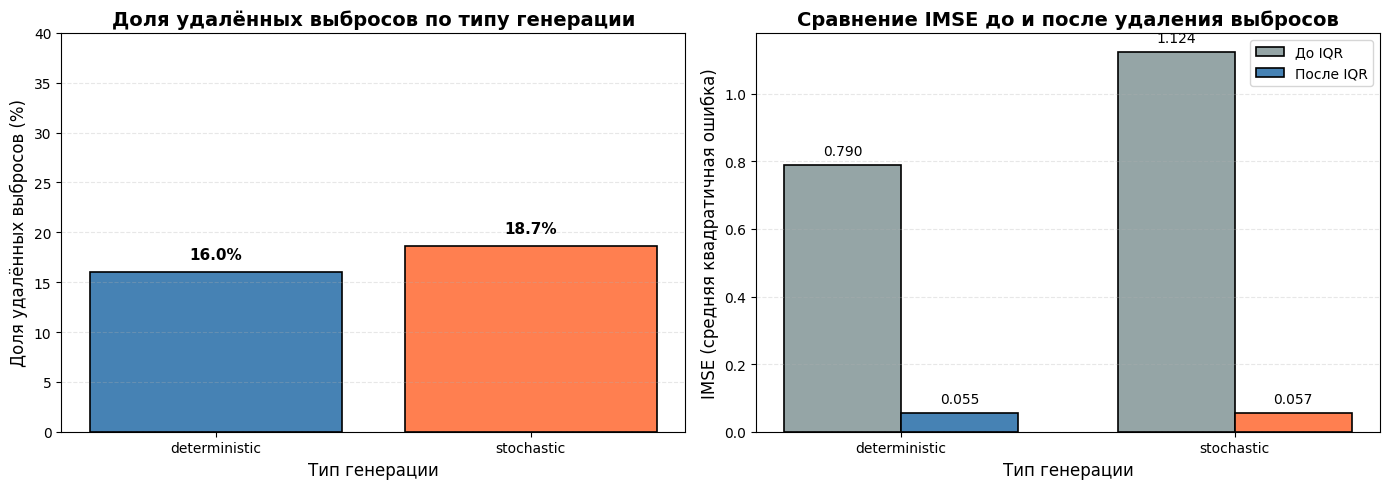


ТАБЛИЦА ДЛЯ ОТЧЁТА
Тип генерации  Удалено выбросов (%)  IMSE до  IMSE после  Улучшение IMSE (%)
deterministic                  16.0   0.7903      0.0554                93.0
   stochastic                  18.7   1.1241      0.0565                95.0


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка данных
df_before = pd.read_csv('entropy_mixture_results_before_iqr.csv')
df_after = pd.read_csv('entropy_mixture_results_after_iqr.csv')

# Объединение данных для анализа
df_merged = pd.merge(
    df_before[['generation_type', 'n_total', 'n_valid', 'imse_mean']], 
    df_after[['generation_type', 'n_valid', 'n_outliers_removed', 'imse_mean']], 
    on='generation_type', 
    suffixes=('_before', '_after')
)

# Расчет метрик
df_merged['removal_rate'] = df_merged['n_outliers_removed'] / df_merged['n_valid_before'] * 100
df_merged['imse_reduction'] = (df_merged['imse_mean_before'] - df_merged['imse_mean_after']) / df_merged['imse_mean_before'] * 100

print("=" * 70)
print("АНАЛИЗ ВЛИЯНИЯ УДАЛЕНИЯ ВЫБРОСОВ (IQR)")
print("=" * 70)
print("\nСводная таблица:")
print(df_merged.to_string(index=False))
print("\n" + "=" * 70)
print("КЛЮЧЕВЫЕ МЕТРИКИ")
print("=" * 70)
for _, row in df_merged.iterrows():
    print(f"\n{row['generation_type'].upper()}:")
    print(f"  • Доля удалённых выбросов: {row['removal_rate']:.1f}%")
    print(f"  • Уменьшение IMSE: {row['imse_reduction']:.1f}%")

# Визуализация - 2 графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Доля удалённых точек по генерациям
colors = ['steelblue', 'coral']
bars1 = axes[0].bar(df_merged['generation_type'], df_merged['removal_rate'], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Тип генерации', fontsize=12)
axes[0].set_ylabel('Доля удалённых выбросов (%)', fontsize=12)
axes[0].set_title('Доля удалённых выбросов по типу генерации', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, 40)

# Добавляем значения на столбцы
for bar, val in zip(bars1, df_merged['removal_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# График 2: Сравнение IMSE до и после очистки
x = np.arange(len(df_merged))
width = 0.35

bars2a = axes[1].bar(x - width/2, df_merged['imse_mean_before'], width, label='До IQR', color='#95a5a6', edgecolor='black', linewidth=1.2)
bars2b = axes[1].bar(x + width/2, df_merged['imse_mean_after'], width, label='После IQR', color=['steelblue', 'coral'], edgecolor='black', linewidth=1.2)

axes[1].set_xlabel('Тип генерации', fontsize=12)
axes[1].set_ylabel('IMSE (средняя квадратичная ошибка)', fontsize=12)
axes[1].set_title('Сравнение IMSE до и после удаления выбросов', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_merged['generation_type'])
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
for bar in bars2a:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2b:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('outlier_removal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Дополнительная таблица для отчёта
print("\n" + "=" * 70)
print("ТАБЛИЦА ДЛЯ ОТЧЁТА")
print("=" * 70)
report_df = pd.DataFrame({
    'Тип генерации': df_merged['generation_type'],
    'Удалено выбросов (%)': df_merged['removal_rate'].round(1),
    'IMSE до': df_merged['imse_mean_before'].round(4),
    'IMSE после': df_merged['imse_mean_after'].round(4),
    'Улучшение IMSE (%)': df_merged['imse_reduction'].round(1)
})
print(report_df.to_string(index=False))

АНАЛИЗ РЕЗУЛЬТАТОВ ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ (IQR)

Исходные данные:
generation_type  method  n_total  n_valid  n_outliers_removed  imse_mean  imse_sem  imae_mean  imae_sem  maxerr_mean  maxerr_sem
  deterministic entropy      600      252                  48   0.055350  0.001993   0.155598   0.00332     0.410550    0.013743
     stochastic entropy      600      244                  56   0.056509  0.002167   0.158016   0.00359     0.390653    0.013358

95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (mean ± 1.96 * SEM)

DETERMINISTIC:
  IMSE:  0.0554 [0.0514, 0.0593]
  IMAE:  0.1556 [0.1491, 0.1621]
  MaxErr: 0.4105 [0.3836, 0.4375]

STOCHASTIC:
  IMSE:  0.0565 [0.0523, 0.0608]
  IMAE:  0.1580 [0.1510, 0.1651]
  MaxErr: 0.3907 [0.3645, 0.4168]


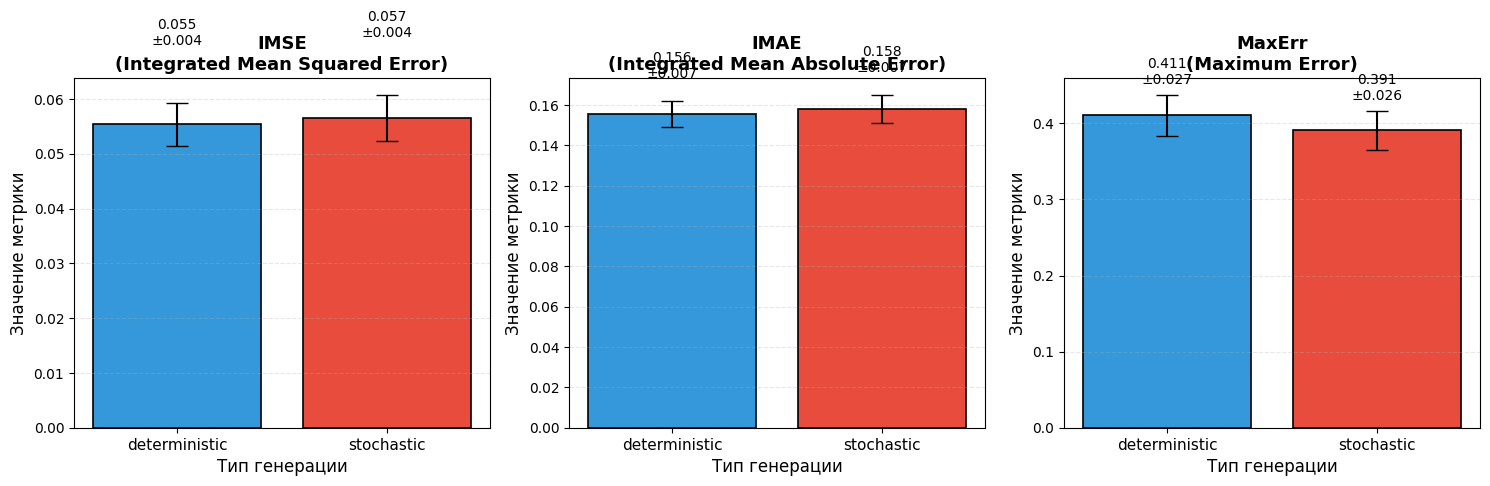


СВОДНАЯ ТАБЛИЦА ДЛЯ ОТЧЁТА
Тип генерации IMSE (mean ± 95% CI) IMAE (mean ± 95% CI) MaxErr (mean ± 95% CI)  N валидных  Удалено выбросов
deterministic      0.0554 ± 0.0039      0.1556 ± 0.0065        0.4105 ± 0.0269         252                48
   stochastic      0.0565 ± 0.0042      0.1580 ± 0.0070        0.3907 ± 0.0262         244                56

СРАВНЕНИЕ МЕЖДУ ГЕНЕРАЦИЯМИ

Разница IMSE (stochastic - deterministic): 0.0012 (+2.1%)
Разница IMAE (stochastic - deterministic): 0.0024 (+1.6%)
Разница MaxErr (stochastic - deterministic): -0.0199 (-4.8%)

ПЕРЕКРЫТИЕ 95% ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ
IMSE: ✅ ПЕРЕКРЫВАЮТСЯ [det: 0.0514-0.0593, stoch: 0.0523-0.0608]
IMAE: ✅ ПЕРЕКРЫВАЮТСЯ [det: 0.1491-0.1621, stoch: 0.1510-0.1651]
MaxErr: ✅ ПЕРЕКРЫВАЮТСЯ [det: 0.3836-0.4375, stoch: 0.3645-0.4168]


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('entropy_mixture_results_after_iqr.csv')

print("=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ (IQR)")
print("=" * 70)
print("\nИсходные данные:")
print(df.to_string(index=False))

# Расчет 95% доверительных интервалов (mean ± 1.96 * SEM)
df['imse_ci_lower'] = df['imse_mean'] - 1.96 * df['imse_sem']
df['imse_ci_upper'] = df['imse_mean'] + 1.96 * df['imse_sem']
df['imae_ci_lower'] = df['imae_mean'] - 1.96 * df['imae_sem']
df['imae_ci_upper'] = df['imae_mean'] + 1.96 * df['imae_sem']
df['maxerr_ci_lower'] = df['maxerr_mean'] - 1.96 * df['maxerr_sem']
df['maxerr_ci_upper'] = df['maxerr_mean'] + 1.96 * df['maxerr_sem']

print("\n" + "=" * 70)
print("95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (mean ± 1.96 * SEM)")
print("=" * 70)
for _, row in df.iterrows():
    print(f"\n{row['generation_type'].upper()}:")
    print(f"  IMSE:  {row['imse_mean']:.4f} [{row['imse_ci_lower']:.4f}, {row['imse_ci_upper']:.4f}]")
    print(f"  IMAE:  {row['imae_mean']:.4f} [{row['imae_ci_lower']:.4f}, {row['imae_ci_upper']:.4f}]")
    print(f"  MaxErr: {row['maxerr_mean']:.4f} [{row['maxerr_ci_lower']:.4f}, {row['maxerr_ci_upper']:.4f}]")

# Визуализация - 3 графика
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('imse_mean', 'imse_sem', 'IMSE\n(Integrated Mean Squared Error)', '#3498db'),
    ('imae_mean', 'imae_sem', 'IMAE\n(Integrated Mean Absolute Error)', '#2ecc71'),
    ('maxerr_mean', 'maxerr_sem', 'MaxErr\n(Maximum Error)', '#e74c3c')
]

x_pos = np.arange(len(df))
colors = ['#3498db', '#e74c3c']  # deterministic, stochastic

for ax, (mean_col, sem_col, title, color) in zip(axes, metrics):
    means = df[mean_col].values
    errors = 1.96 * df[sem_col].values  # 95% CI
    
    bars = ax.bar(x_pos, means, yerr=errors, capsize=8, color=colors, 
                  edgecolor='black', linewidth=1.2, error_kw={'elinewidth': 1.5})
    
    ax.set_xlabel('Тип генерации', fontsize=12)
    ax.set_ylabel('Значение метрики', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df['generation_type'], fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Добавляем значения на столбцы
    for bar, mean, err in zip(bars, means, errors):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.01, 
                f'{mean:.3f}\n±{err:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('metrics_comparison_after_iqr.png', dpi=150, bbox_inches='tight')
plt.show()

# Сводная таблица для отчёта
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА ДЛЯ ОТЧЁТА")
print("=" * 70)
report_df = pd.DataFrame({
    'Тип генерации': df['generation_type'],
    'IMSE (mean ± 95% CI)': df.apply(lambda r: f"{r['imse_mean']:.4f} ± {1.96*r['imse_sem']:.4f}", axis=1),
    'IMAE (mean ± 95% CI)': df.apply(lambda r: f"{r['imae_mean']:.4f} ± {1.96*r['imae_sem']:.4f}", axis=1),
    'MaxErr (mean ± 95% CI)': df.apply(lambda r: f"{r['maxerr_mean']:.4f} ± {1.96*r['maxerr_sem']:.4f}", axis=1),
    'N валидных': df['n_valid'],
    'Удалено выбросов': df['n_outliers_removed']
})
print(report_df.to_string(index=False))

# Сравнение между генерациями
print("\n" + "=" * 70)
print("СРАВНЕНИЕ МЕЖДУ ГЕНЕРАЦИЯМИ")
print("=" * 70)
det = df[df['generation_type'] == 'deterministic'].iloc[0]
stoch = df[df['generation_type'] == 'stochastic'].iloc[0]

print(f"\nРазница IMSE (stochastic - deterministic): {stoch['imse_mean'] - det['imse_mean']:.4f} "
      f"({(stoch['imse_mean'] - det['imse_mean'])/det['imse_mean']*100:+.1f}%)")
print(f"Разница IMAE (stochastic - deterministic): {stoch['imae_mean'] - det['imae_mean']:.4f} "
      f"({(stoch['imae_mean'] - det['imae_mean'])/det['imae_mean']*100:+.1f}%)")
print(f"Разница MaxErr (stochastic - deterministic): {stoch['maxerr_mean'] - det['maxerr_mean']:.4f} "
      f"({(stoch['maxerr_mean'] - det['maxerr_mean'])/det['maxerr_mean']*100:+.1f}%)")

# Проверка перекрытия доверительных интервалов
print("\n" + "=" * 70)
print("ПЕРЕКРЫТИЕ 95% ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ")
print("=" * 70)

for metric_name, mean_col, sem_col in [('IMSE', 'imse_mean', 'imse_sem'), 
                                         ('IMAE', 'imae_mean', 'imae_sem'), 
                                         ('MaxErr', 'maxerr_mean', 'maxerr_sem')]:
    det_lower = det[mean_col] - 1.96 * det[sem_col]
    det_upper = det[mean_col] + 1.96 * det[sem_col]
    stoch_lower = stoch[mean_col] - 1.96 * stoch[sem_col]
    stoch_upper = stoch[mean_col] + 1.96 * stoch[sem_col]
    
    overlap = not (det_upper < stoch_lower or stoch_upper < det_lower)
    print(f"{metric_name}: {'✅ ПЕРЕКРЫВАЮТСЯ' if overlap else '❌ НЕ перекрываются'} "
          f"[det: {det_lower:.4f}-{det_upper:.4f}, stoch: {stoch_lower:.4f}-{stoch_upper:.4f}]")